# A1-1 쇼핑몰 고객 분석과 RFM 세분화

이 노트북은 공개 거래 데이터를 불러와 결측치와 이상치를 처리하고, 숫자·텍스트·이미지 배열 특징을 만든 뒤 RFM으로 고객을 네 그룹으로 분류한다. 모든 결과는 `src/pipeline.py`의 재사용 가능한 `DataAnalyzer`를 통해 계산한다.

## 1. 데이터 출처와 분석 설계

- 출처: UCI Machine Learning Repository, **Online Retail**
- DOI: <https://doi.org/10.24432/C5BW33>
- 라이선스: CC BY 4.0
- 원본: 541,909행, 8개 원본 필드, 2010-12-01~2011-12-09
- 분석 표본: seed 42로 재현 가능하게 추출한 25,000행, 14개 열

`product_image`는 실제 상품 사진이라고 주장하지 않는다. `stock_code`에서 결정론적으로 만든 8×8 교육용 배열이며, CSV 문자열을 `np.fromstring`으로 읽어 배열 평균과 표준편차를 반복문 없이 계산한다. RFM 기준일은 마지막 유효 구매일 다음 날이다.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import json
import numpy as np
import pandas as pd

from src.pipeline import DataAnalyzer

pd.set_option("display.max_columns", 30)
DATA_PATH = Path("data/online_retail_sample.csv")
FIGURES = Path("figures")
OUTPUTS = Path("outputs")

## 2. 데이터 로드와 기본 탐색

In [2]:
analyzer = DataAnalyzer(DATA_PATH, outlier_threshold=1.5)
df = analyzer.load_data()
print(f"shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.drop(columns="product_image").head())
df.info()

shape: 25,000 rows × 14 columns


,row_id,source_row_id,invoice_no,stock_code,description,quantity,order_date,unit_price,customer_id,country,amount,image_height,image_width
0,0,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,8
1,1,31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,8,8
2,2,53,536373,37370,RETRO COFFEE MUGS ASSORTED,6,2010-12-01 09:02:00,1.06,17850.0,United Kingdom,6.36,8,8
3,3,112,536381,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,24,2010-12-01 09:41:00,1.25,15311.0,United Kingdom,30.00,8,8
4,4,123,536381,22083,PAPER CHAIN KIT RETROSPOT,1,2010-12-01 09:41:00,2.95,15311.0,United Kingdom,2.95,8,8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         25000 non-null  int64         
 1   source_row_id  25000 non-null  int64         
 2   invoice_no     25000 non-null  object        
 3   stock_code     25000 non-null  object        
 4   description    24935 non-null  object        
 5   quantity       25000 non-null  int64         
 6   order_date     25000 non-null  datetime64[ns]
 7   unit_price     25000 non-null  float64       
 8   customer_id    18700 non-null  float64       
 9   country        25000 non-null  object        
 10  amount         25000 non-null  float64       
 11  product_image  25000 non-null  object        
 12  image_height   25000 non-null  int64         
 13  image_width    25000 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(5)
memory usage: 2.

In [3]:
overview = analyzer.overview()
display(pd.Series(overview["missing_by_column"], name="missing_count").to_frame())
display(df.select_dtypes(include="number").describe().T)

,missing_count
row_id,0
source_row_id,0
invoice_no,0
stock_code,0
description,65
quantity,0
order_date,0
unit_price,0
customer_id,6300
country,0


,count,mean,std,min,25%,50%,75%,max
row_id,25000.0,12499.500000,7217.022701,0.0,6249.75,12499.50,18749.25,24999.00
source_row_id,25000.0,271052.645280,156655.821988,2.0,135444.00,270820.50,406505.50,541898.00
quantity,25000.0,9.505600,43.222214,-2376.0,1.00,3.00,10.00,2880.00
unit_price,25000.0,5.111353,120.066142,0.0,1.25,2.08,4.13,13541.33
customer_id,18700.0,15257.567166,1713.557230,12347.0,13899.75,15078.00,16764.00,18287.00
amount,25000.0,17.487655,131.268746,-11586.5,3.38,9.75,17.40,13541.33
image_height,25000.0,8.000000,0.000000,8.0,8.00,8.00,8.00,8.00
image_width,25000.0,8.000000,0.000000,8.0,8.00,8.00,8.00,8.00


### 탐색 해석

수치형, 문자열형, 날짜형, NumPy 배열형이 함께 존재한다. 실제 표본에서 `description` 65건과 `customer_id` 6,300건의 결측을 확인했다. 고객 ID는 식별자이므로 평균이나 임의 값으로 채우면 서로 다른 고객을 합치는 오류가 생긴다. 따라서 설명은 상품 그룹의 최빈값으로 보완하고, 고객 ID 결측은 보존했다가 RFM 집계에서만 제외한다.

## 3. 결측치 처리와 멀티모달 특징 공학

In [4]:
missing_report = analyzer.handle_missing_values(strategy="group_mode", group_col="stock_code")
display(pd.DataFrame(missing_report))

df = analyzer.engineer_features()
display(df[["quantity", "unit_price", "amount", "description", "word_count", "image_mean", "image_std"]].head())

,before,after
row_id,0,0
source_row_id,0,0
invoice_no,0,0
stock_code,0,0
description,65,0
quantity,0,0
order_date,0,0
unit_price,0,0
customer_id,6300,6300
country,0,0


,quantity,unit_price,amount,description,word_count,image_mean,image_std
0,8,2.75,22.00,CREAM CUPID HEARTS COAT HANGER,5,127.0,73.891813
1,48,0.85,40.80,INFLATABLE POLITICAL GLOBE,3,127.5,72.368847
2,6,1.06,6.36,RETRO COFFEE MUGS ASSORTED,4,129.0,73.864741
3,24,1.25,30.00,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,5,128.5,74.318571
4,1,2.95,2.95,PAPER CHAIN KIT RETROSPOT,4,126.0,72.090221


- 숫자: `amount = quantity × unit_price`를 NumPy 벡터 연산으로 계산했다.
- 텍스트: 상품 설명을 공백 단위로 나눈 `word_count`를 생성했다.
- 이미지 배열: 25,000×64 행렬로 쌓아 행 방향 `mean`과 `std`를 한 번에 계산했다.

이 방식은 Python `for` 반복으로 개별 픽셀을 계산하는 것보다 간결하고, 실제 계산을 최적화된 NumPy 루틴에 위임한다.

## 4. IQR 이상치 탐지와 처리

\[
IQR = Q_3 - Q_1, \quad
Lower = Q_1 - 1.5IQR, \quad
Upper = Q_3 + 1.5IQR
\]

반품과 취소는 음수라는 비즈니스 의미가 있으므로 별도로 보존하고, 양수 구매 금액의 극단값만 상한·하한으로 클리핑했다. 원본 `amount`도 남겨 처리 전후를 검증할 수 있게 했다.

column                                                      amount
method                                                        clip
output_column                                         amount_clean
before_count                                                  1925
after_count                                                      0
bounds           {'q1': 3.75, 'q3': 17.700000000000003, 'iqr': ...
dtype: object

IQR positive-purchase outliers: 1,925


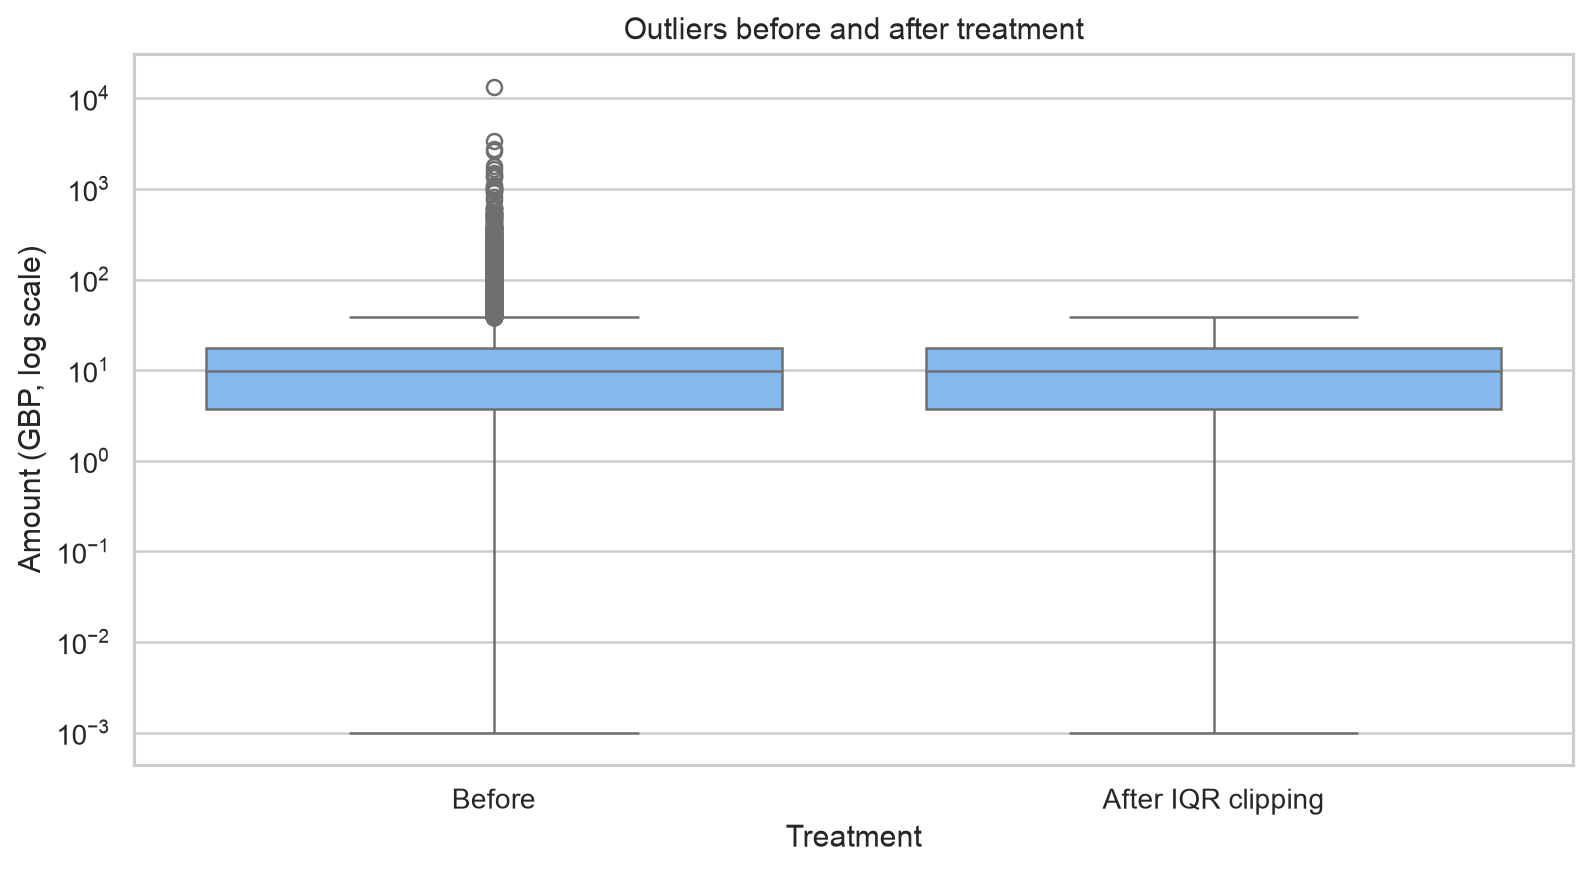

In [5]:
outliers_before = analyzer.detect_outliers("amount", positive_only=True)
outlier_report = analyzer.treat_outliers(
    "amount", method="clip", output_col="amount_clean", positive_only=True
)
display(pd.Series(outlier_report))
print(f"IQR positive-purchase outliers: {len(outliers_before):,}")
display(Image(filename=str(FIGURES / "02_outlier_boxplot.png")))

## 5. 여섯 종류 이상의 시각화

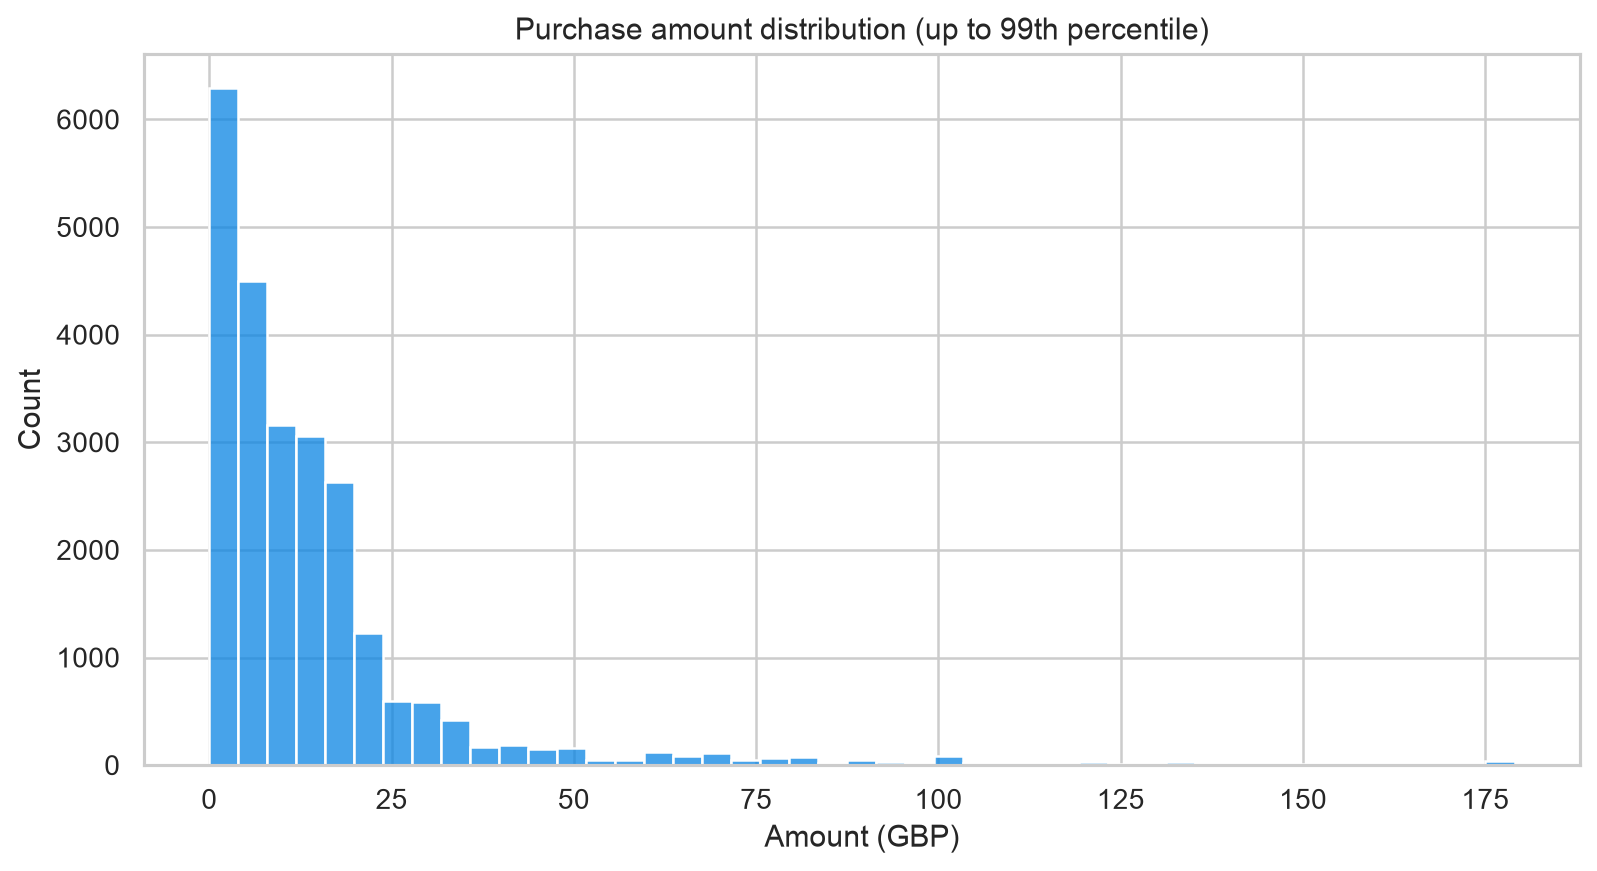

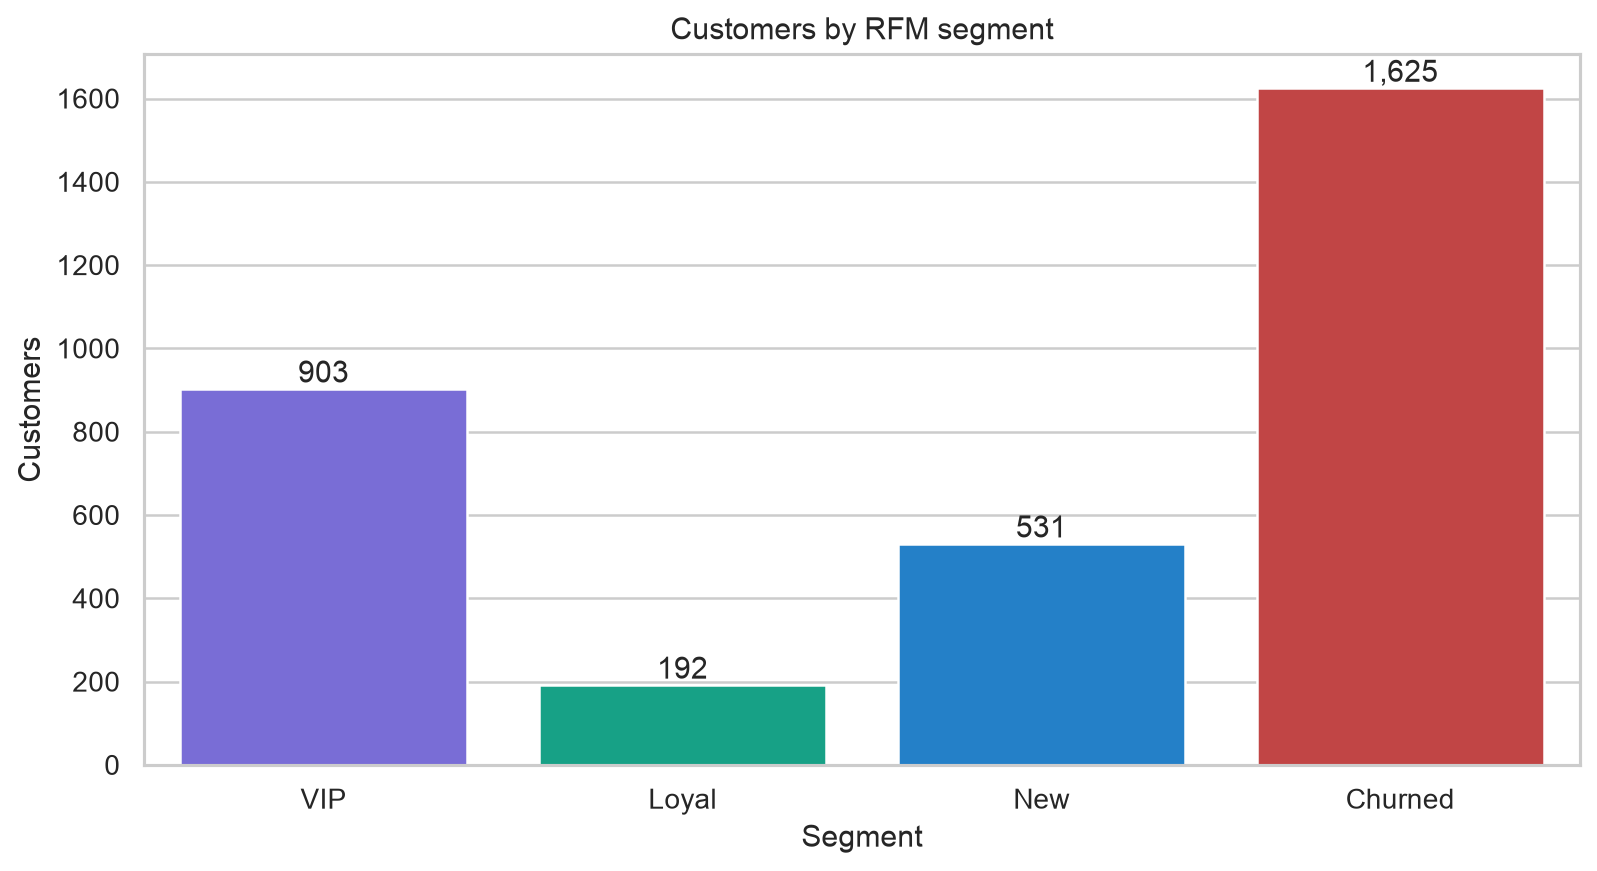

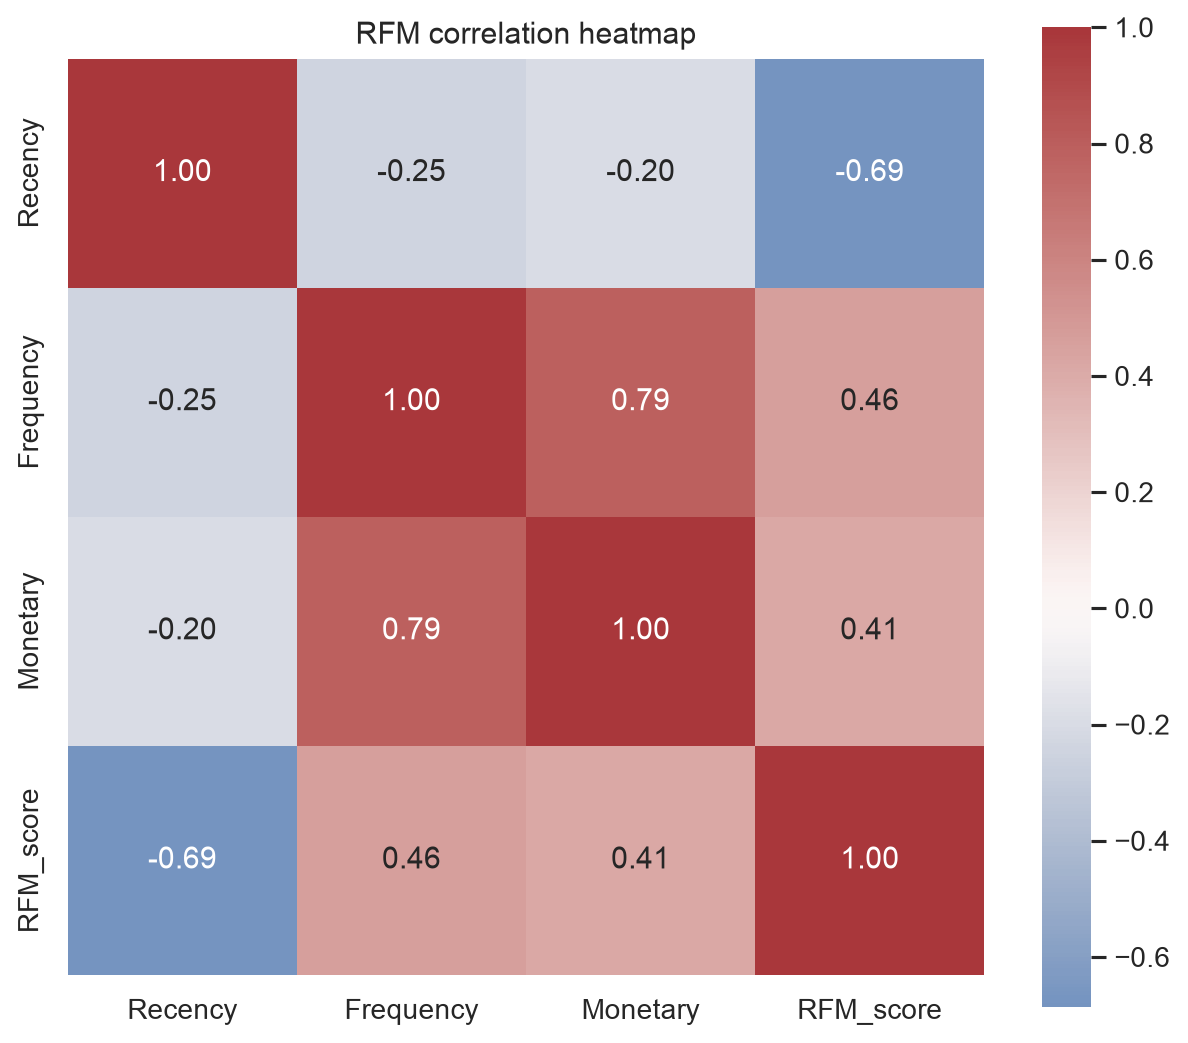

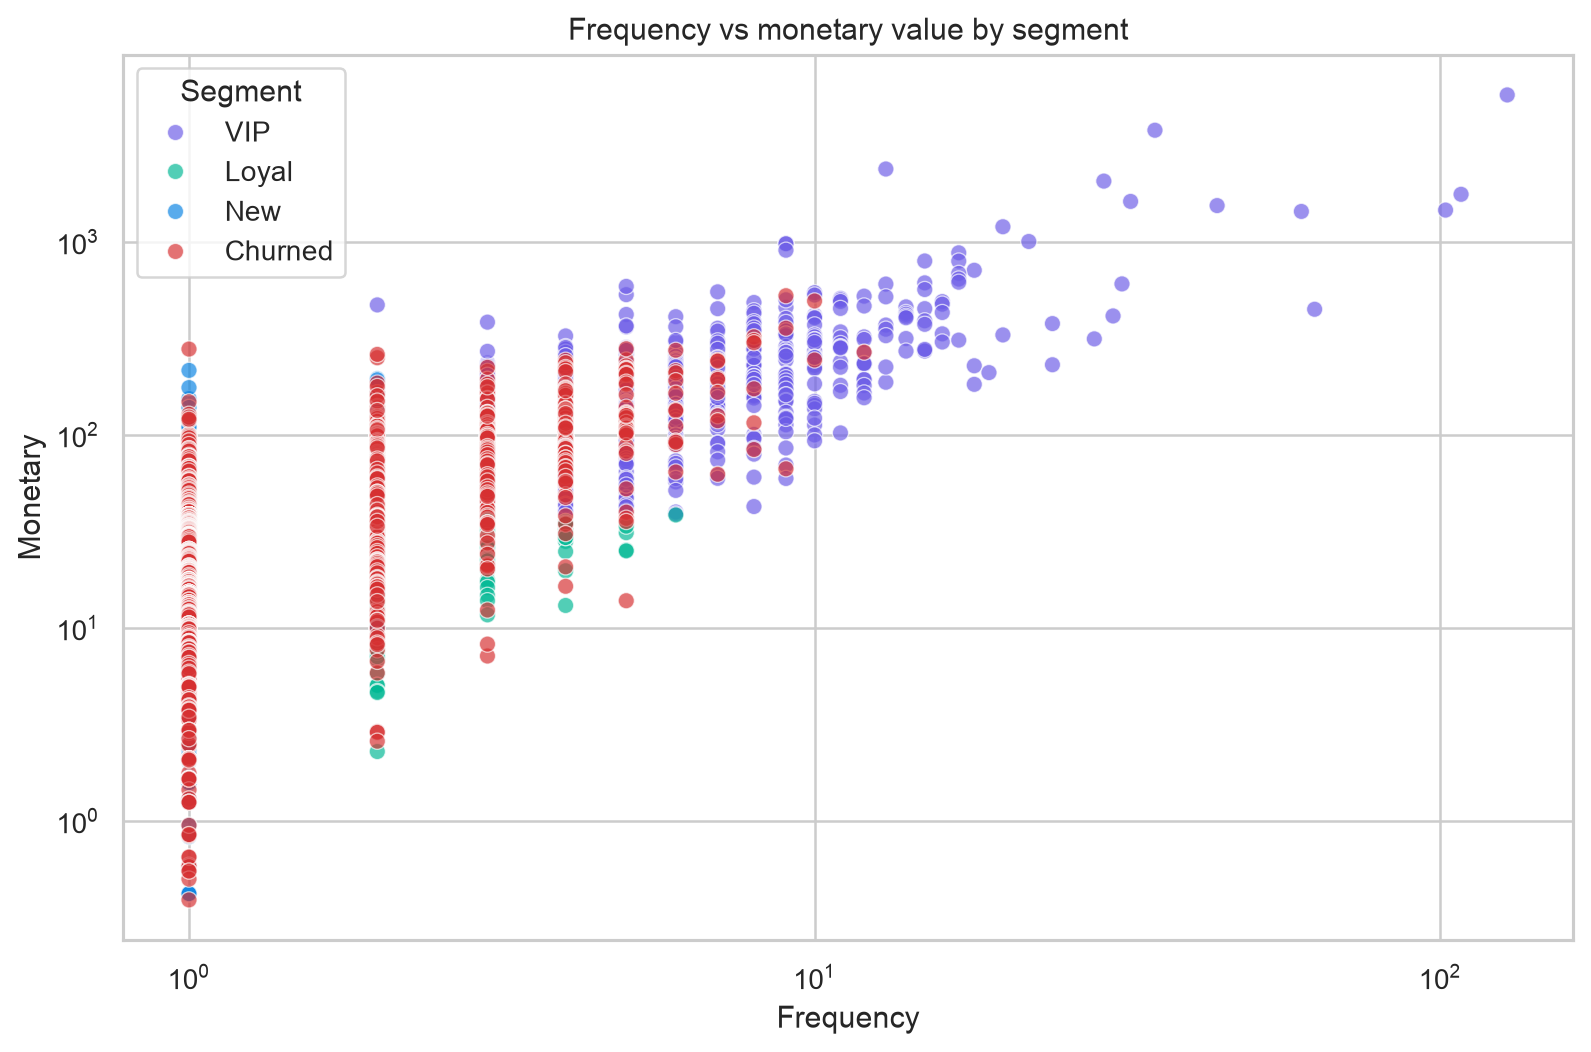

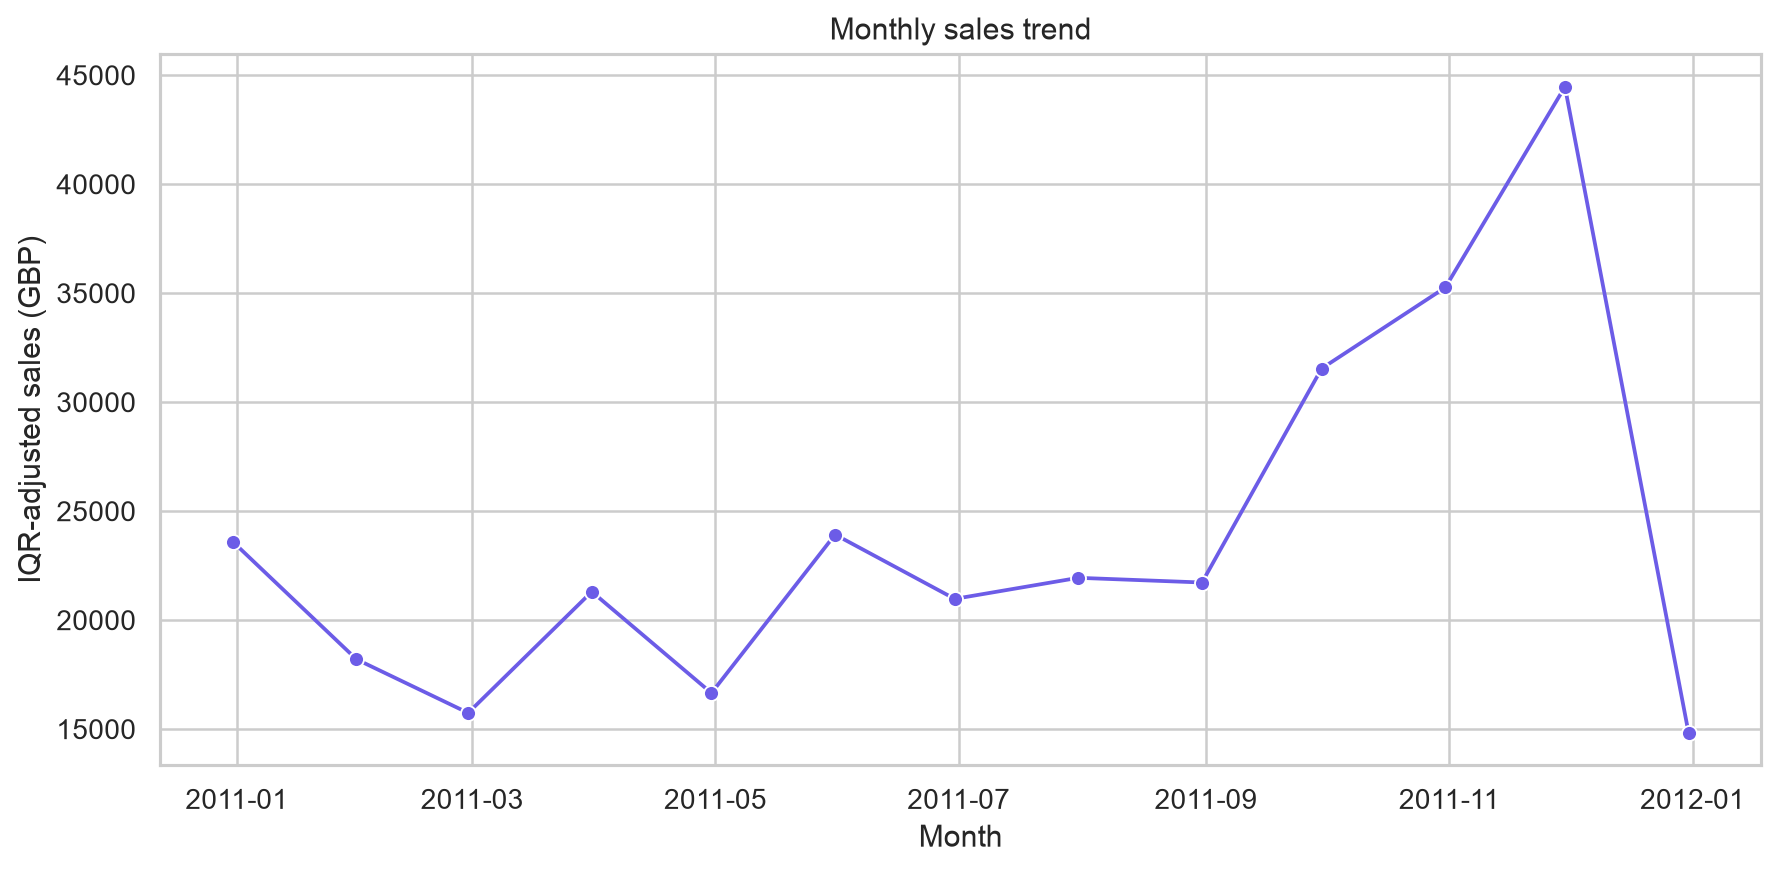

In [6]:
for filename in [
    "01_amount_histogram.png",
    "03_segment_bar.png",
    "04_rfm_heatmap.png",
    "05_rfm_scatter.png",
    "06_monthly_sales_line.png",
]:
    display(Image(filename=str(FIGURES / filename)))

히스토그램은 구매금액의 강한 오른쪽 꼬리를 보여준다. 상관 히트맵에서 Frequency와 Monetary의 상관은 약 0.79로 높지만, 상관관계가 구매 횟수 증가의 인과 효과를 증명하지는 않는다. 월별 추세는 2011년 가을의 상승과 11월 고점을 보여주며, 마지막 12월은 9일까지만 포함된 불완전 월이므로 전월과 직접 비교하면 안 된다.

## 6. RFM 고객 세분화

- Recency: 기준일에서 마지막 구매일까지의 일수(작을수록 좋음)
- Frequency: 서로 다른 주문서 수(클수록 좋음)
- Monetary: IQR 조정된 유효 구매 금액 합계(클수록 좋음)

각 지표를 사분위 점수 1~4로 바꾸고 `VIP`, `Loyal`, `New`, `Churned`로 분류한다. 기준일은 데이터의 마지막 유효 구매일 다음 날인 2011-12-10이다.

In [7]:
rfm = analyzer.calculate_rfm(amount_col="amount_clean")
segment_summary = analyzer.segment_summary()
display(rfm.head(10))
display(segment_summary.style.format({
    "mean_recency": "{:.1f}",
    "mean_frequency": "{:.1f}",
    "mean_monetary": "£{:,.0f}",
    "total_monetary": "£{:,.0f}",
    "customer_share": "{:.1%}",
    "revenue_share": "{:.1%}",
}))

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
customer_id,,,,,,,,
14911,1,128,5786.890,4,4,4,12,VIP
14646,1,35,3797.240,4,4,4,12,VIP
14096,4,13,2390.960,4,4,4,12,VIP
14298,8,29,2069.470,4,4,4,12,VIP
17841,1,108,1767.990,4,4,4,12,VIP
14156,23,32,1624.200,4,4,4,12,VIP
13089,4,44,1545.370,4,4,4,12,VIP
12748,1,102,1464.495,4,4,4,12,VIP
15311,0,60,1441.020,4,4,4,12,VIP


,customers,mean_recency,median_frequency,mean_frequency,mean_monetary,total_monetary,customer_share,revenue_share
Segment,,,,,,,,
VIP,903,21.2,4.000000,6.0,£180,"£162,839",27.8%,63.4%
Churned,1625,179.5,1.000000,1.7,£45,"£73,917",50.0%,28.8%
New,531,31.2,1.000000,1.1,£29,"£15,369",16.3%,6.0%
Loyal,192,27.6,2.000000,2.5,£25,"£4,795",5.9%,1.9%


Recency                               Frequency                   \
          count        mean median        std     count      mean median   
Segment                                                                    
Churned    1625  179.481846  162.0  92.356218      1625  1.701538    1.0   
Loyal       192   27.609375   26.0  17.053612       192  2.494792    2.0   
New         531   31.224105   30.0  17.837756       531  1.126177    1.0   
VIP         903   21.205980   18.0  16.510820       903  5.975637    4.0   

                  Monetary                                   
              std    count        mean   median         std  
Segment                                                      
Churned  1.253136     1625   45.487538   32.300   47.986590  
Loyal    0.772549      192   24.975000   26.060    9.002231  
New      0.332362      531   28.943145   19.900   28.972544  
VIP      7.974423      903  180.330854  115.425  296.749308

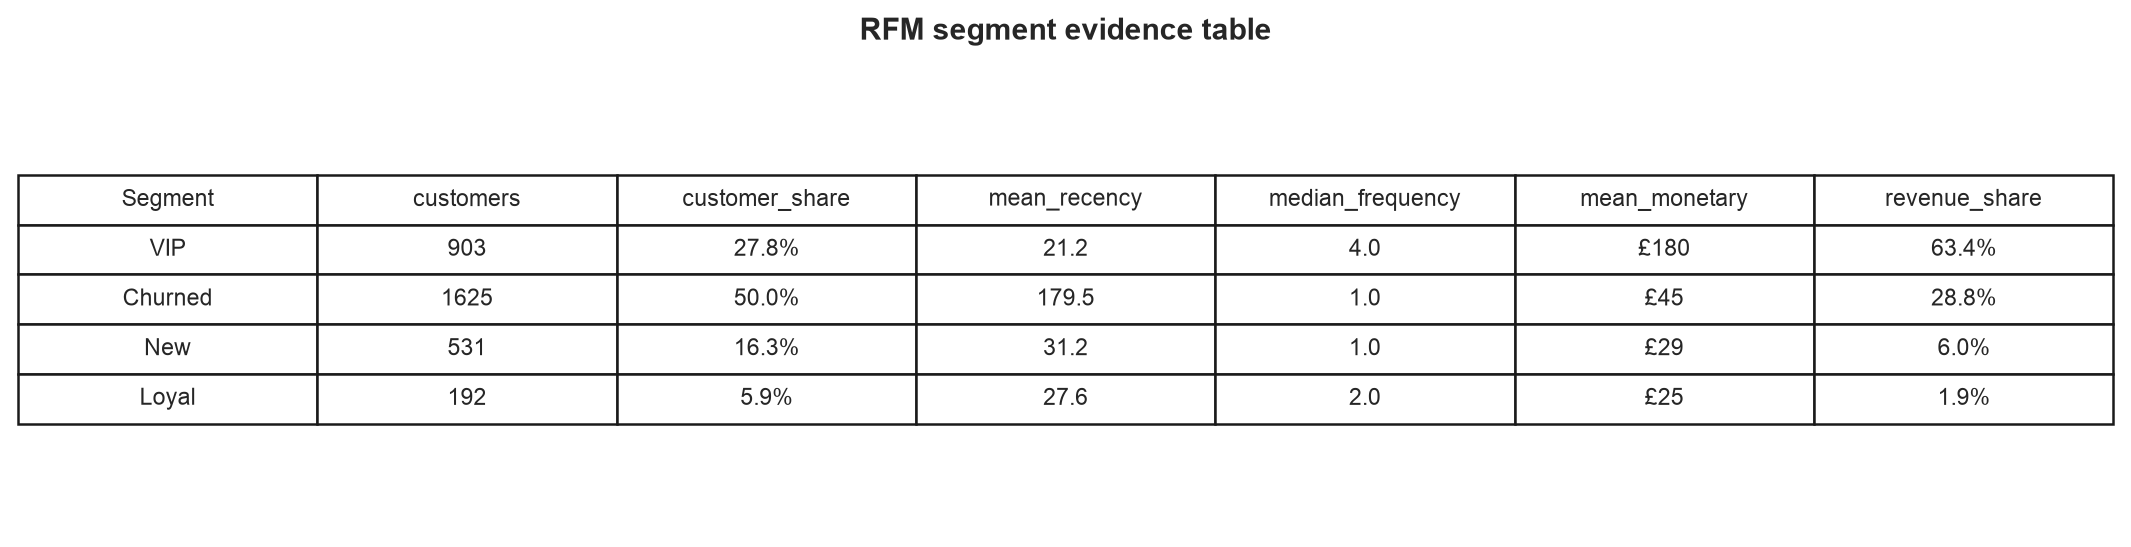

In [8]:
group_statistics = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].agg(
    ["count", "mean", "median", "std"]
)
display(group_statistics)
display(Image(filename=str(FIGURES / "07_segment_summary_table.png")))

## 7. 데이터 근거 기반 비즈니스 제안

1. **VIP 유지** — 근거: VIP는 고객의 27.8%지만 조정 매출의 63.4%를 만든다. 실행: 등급별 선공개와 서비스 혜택을 제공한다. 기대효과: 핵심 매출과 반복구매율 방어. 검증: 캠페인/대조군 반복구매율, 이익률, 혜택 비용, 90일 이탈률이 필요하다.
2. **Churned 재활성화** — 근거: 고객의 50.0%가 Churned이며 평균 Recency는 179.5일이다. 실행: 기간 제한 인센티브를 무작위 대조 실험으로 운영한다. 기대효과: 전체 할인 없이 휴면 고객 회수. 검증: 홀드아웃 대비 증분 매출, 공헌이익, 수신거부율, 이탈 사유 설문이 필요하다.
3. **New의 두 번째 구매 유도** — 근거: New는 531명(16.3%)이고 구매빈도 중앙값은 1회다. 실행: 첫 구매 후 14일 내 사용 가이드와 연관상품 추천을 보낸다. 기대효과: 1회 구매자의 2회차 전환. 검증: 14/30일 2회차 구매율, 클릭률, 반품률, 코호트 유지율이 필요하다.

이 제안들은 관찰 데이터에서 나온 가설이다. 캠페인의 인과 효과를 주장하려면 대조군과 비용·마진 데이터가 추가로 필요하다.

## 8. 한계와 재현성

- 25,000행 표본이므로 전체 541,909행의 정확한 모집단 추정치가 아니다.
- 거래 고객 ID 결측은 RFM에서 제외되어 비식별 구매를 대표하지 못한다.
- `product_image`는 배열 연습용 파생 데이터이며 시각적 상품 특성을 뜻하지 않는다.
- 반품/취소는 RFM 구매 집계에서 제외했지만 별도의 반품 행동 분석이 필요하다.
- 2011년 12월은 부분 월이다.

모든 표본 추출, 특징 생성, 경계값, 기준일은 코드에 명시되어 있다. `python -m scripts.run_analysis`로 산출물을 다시 만들 수 있다.